In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

PROJECT_PATH = Path(
    "/content/drive/MyDrive/churn/Churn_Modelling.csv"
)

DATA_PATH = PROJECT_PATH

print(DATA_PATH)

/content/drive/MyDrive/churn/Churn_Modelling.csv


In [ ]:
import pandas as pd

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
!pip install -q xgboost lightgbm catboost imbalanced-learn shap optuna mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [ ]:

print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

Nombre de lignes : 10000
Nombre de colonnes : 14


In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [ ]:
print("Liste des variables :")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Liste des variables :
1. RowNumber
2. CustomerId
3. Surname
4. CreditScore
5. Geography
6. Gender
7. Age
8. Tenure
9. Balance
10. NumOfProducts
11. HasCrCard
12. IsActiveMember
13. EstimatedSalary
14. Exited


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
print("Nombre de doublons :", df.duplicated().sum())

Nombre de doublons : 0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [ ]:
TARGET = "Exited"
print(df[TARGET].value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64


In [ ]:
print(df[TARGET].value_counts(normalize=True).mul(100).round(2))

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


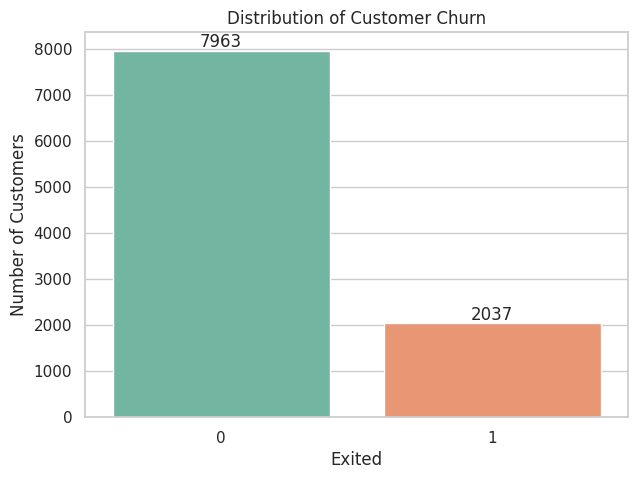

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="Exited",
    hue="Exited",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Customer Churn")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [ ]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

for col in categorical_columns:
    print("\n" + "="*50)
    print(f"Variable : {col}")
    print(df[col].value_counts())


Variable : Surname
Surname
Smith        32
Scott        29
Martin       29
Walker       28
Brown        26
             ..
Hull          1
Sturdee       1
Flannagan     1
Dwyer         1
Corby         1
Name: count, Length: 2932, dtype: int64

Variable : Geography
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Variable : Gender
Gender
Male      5457
Female    4543
Name: count, dtype: int64


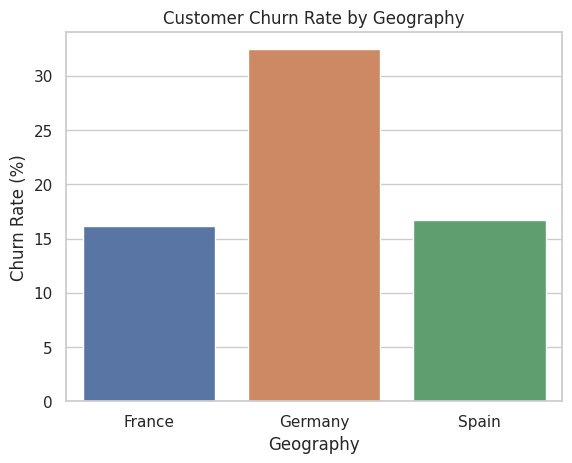

In [ ]:


sns.barplot(
    data=geo_churn,
    x="Geography",
    y="Churn_Rate",
    hue="Geography",
    legend=False
)

plt.title("Customer Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")

plt.show()

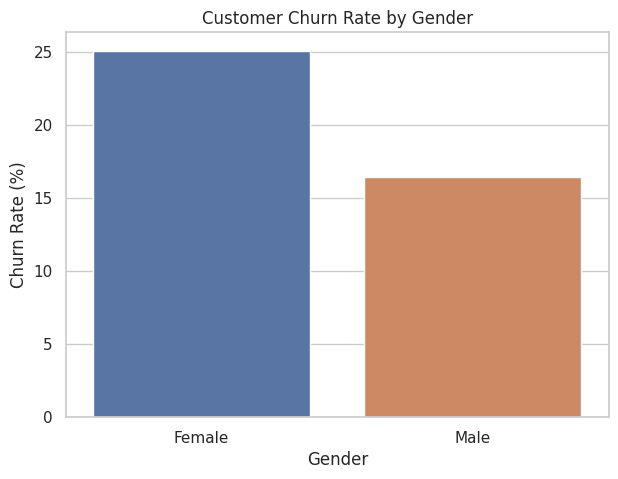

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_churn,
    x="Gender",
    y="Churn_Rate",
    hue="Gender",
    legend=False
)

plt.title("Customer Churn Rate by Gender")
plt.ylabel("Churn Rate (%)")

plt.show()

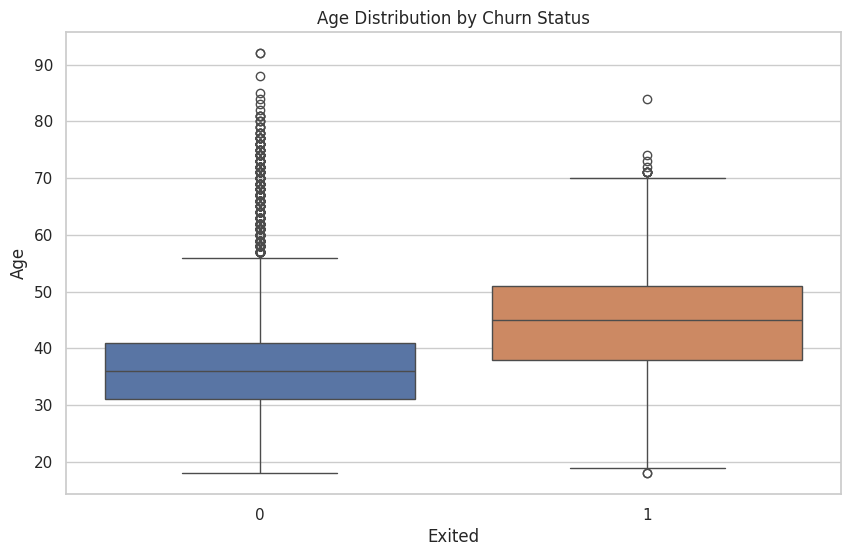

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Exited",
    y="Age",
    hue="Exited",
    legend=False
)

plt.title("Age Distribution by Churn Status")
plt.xlabel("Exited")
plt.ylabel("Age")

plt.show()

In [ ]:
df.groupby("Exited")["Age"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
Exited,,,,,,
0,7963,37.408389,36.0,10.125363,18,92
1,2037,44.837997,45.0,9.761562,18,84


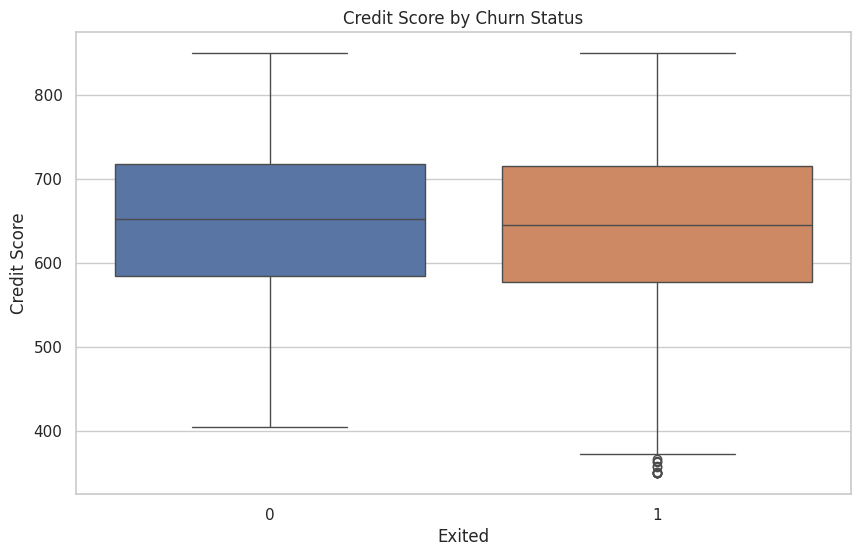

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Exited",
    y="CreditScore",
    hue="Exited",
    legend=False
)

plt.title("Credit Score by Churn Status")
plt.xlabel("Exited")
plt.ylabel("Credit Score")

plt.show()

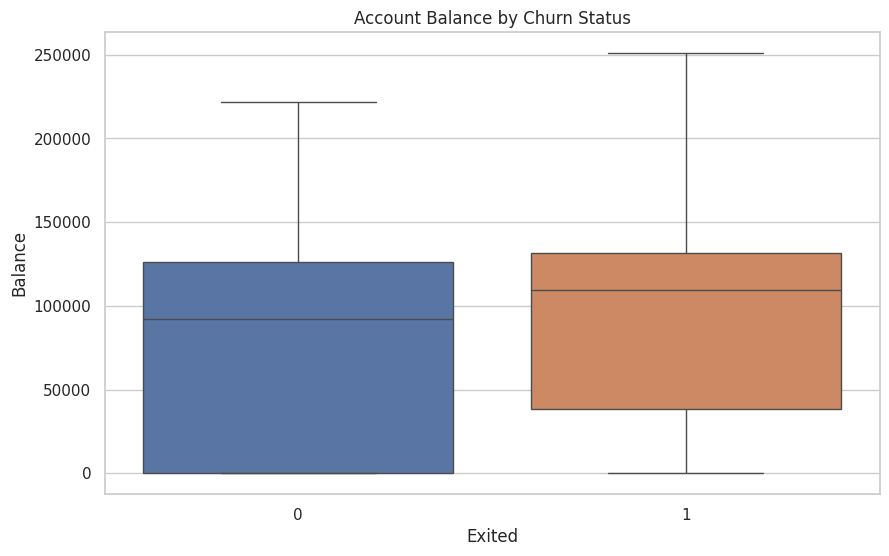

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Exited",
    y="Balance",
    hue="Exited",
    legend=False
)

plt.title("Account Balance by Churn Status")
plt.xlabel("Exited")
plt.ylabel("Balance")

plt.show()

In [ ]:
activity_churn = (
    df.groupby("IsActiveMember")["Exited"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

activity_churn.columns = [
    "IsActiveMember",
    "Total_Customers",
    "Churned_Customers",
    "Churn_Rate"
]

activity_churn["Churn_Rate"] *= 100

activity_churn

,IsActiveMember,Total_Customers,Churned_Customers,Churn_Rate
0,0,4849,1302,26.850897
1,1,5151,735,14.269074


In [ ]:
product_churn = (
    df.groupby("NumOfProducts")["Exited"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

product_churn.columns = [
    "NumOfProducts",
    "Total_Customers",
    "Churned_Customers",
    "Churn_Rate"
]

product_churn["Churn_Rate"] *= 100

product_churn

,NumOfProducts,Total_Customers,Churned_Customers,Churn_Rate
0,1,5084,1409,27.714398
1,2,4590,348,7.581699
2,3,266,220,82.706767
3,4,60,60,100.000000


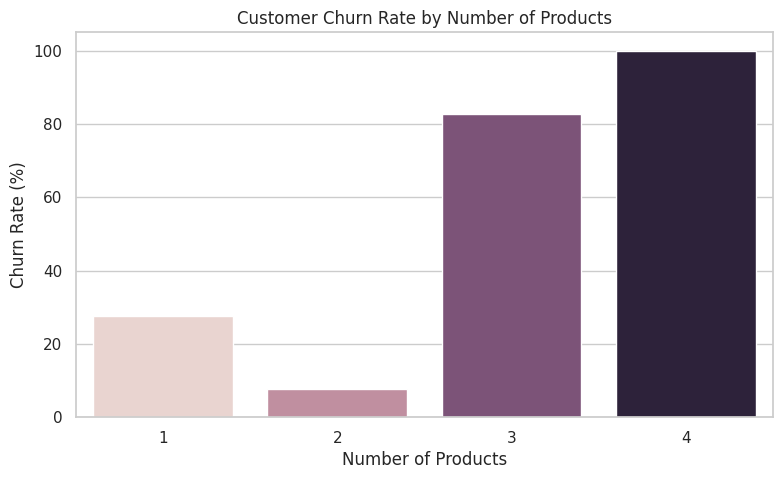

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=product_churn,
    x="NumOfProducts",
    y="Churn_Rate",
    hue="NumOfProducts",
    legend=False
)

plt.title("Customer Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")

plt.show()

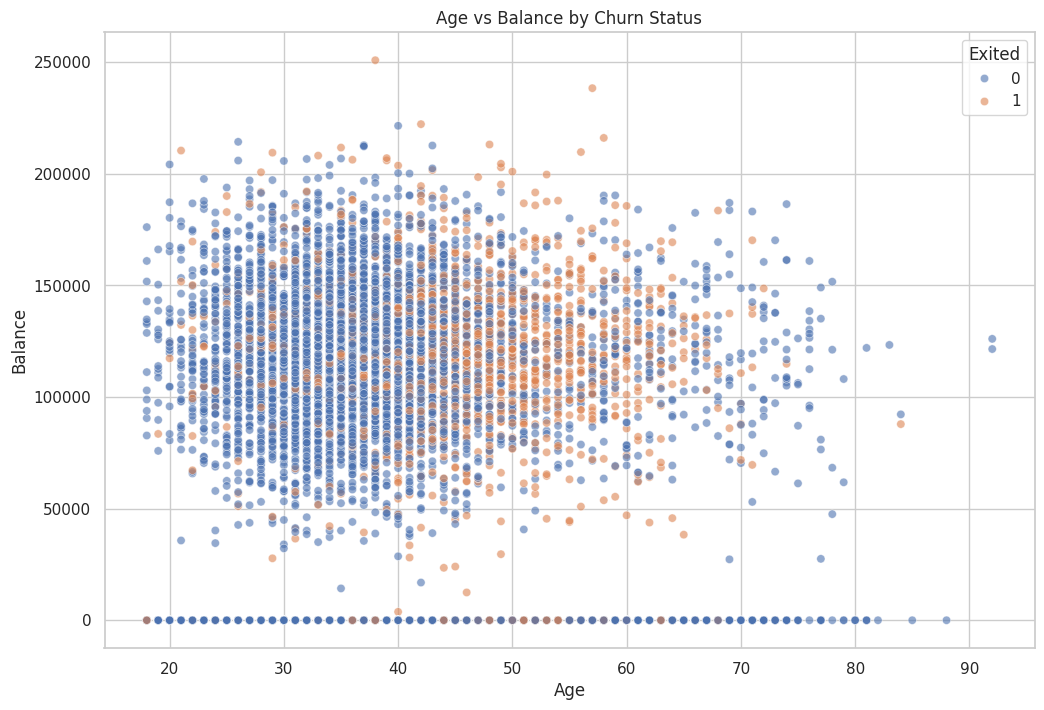

In [ ]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df,
    x="Age",
    y="Balance",
    hue="Exited",
    alpha=0.6
)

plt.title("Age vs Balance by Churn Status")
plt.xlabel("Age")
plt.ylabel("Balance")

plt.show()

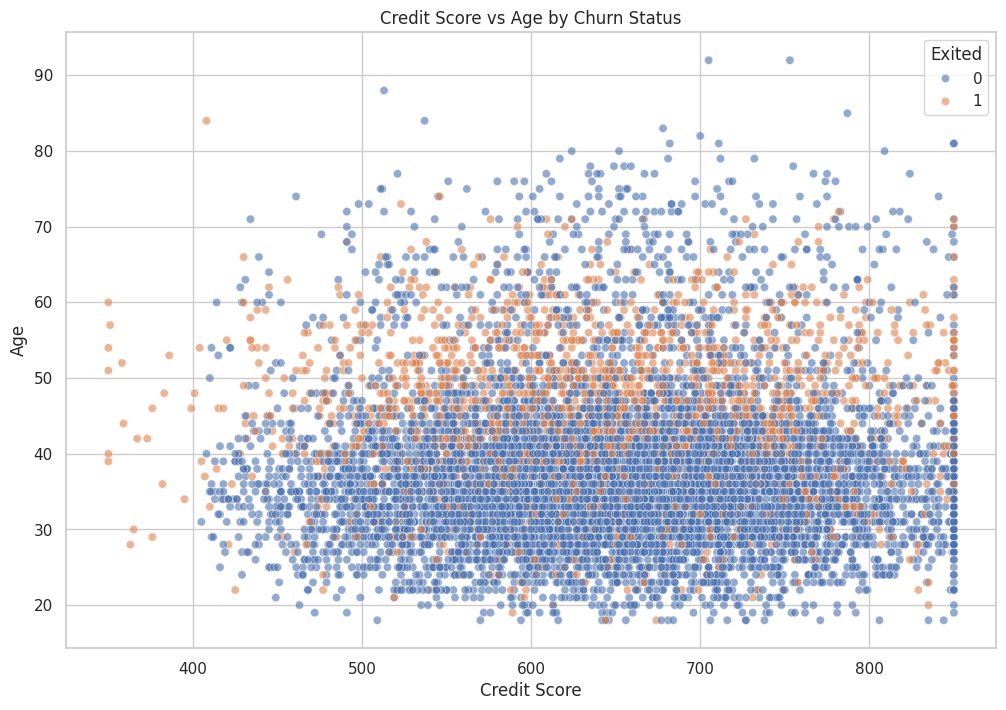

In [ ]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df,
    x="CreditScore",
    y="Age",
    hue="Exited",
    alpha=0.6
)

plt.title("Credit Score vs Age by Churn Status")
plt.xlabel("Credit Score")
plt.ylabel("Age")

plt.show()

In [ ]:
correlation = (
    df[numeric_columns]
    .corr()["Exited"]
    .sort_values(ascending=False)
)

correlation

,Exited
Exited,1.000000
Age,0.285323
Balance,0.118533
EstimatedSalary,0.012097
CustomerId,-0.006248
HasCrCard,-0.007138
Tenure,-0.014001
RowNumber,-0.016571
CreditScore,-0.027094
NumOfProducts,-0.047820


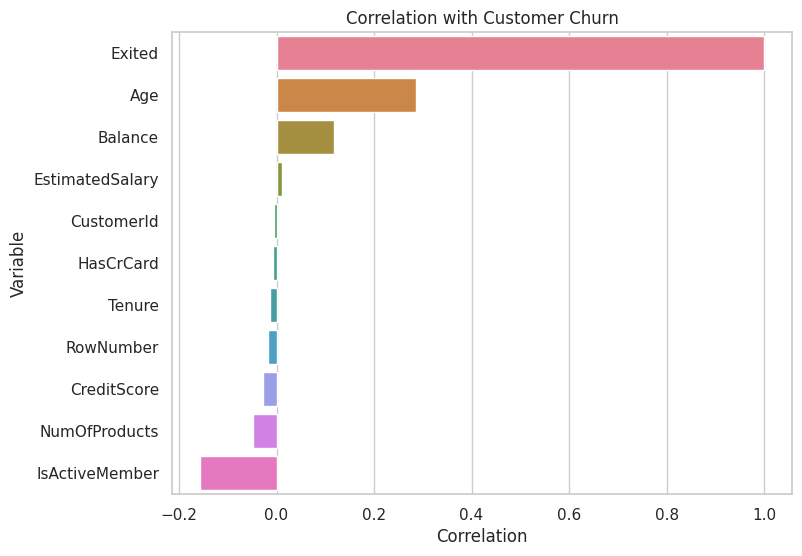

In [ ]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=correlation.values,
    y=correlation.index,
    hue=correlation.index,
    legend=False
)

plt.title("Correlation with Customer Churn")
plt.xlabel("Correlation")
plt.ylabel("Variable")

plt.show()

In [ ]:


ID_COLUMNS = ["RowNumber", "CustomerId", "Surname"]

print("Variables d'identification :", ID_COLUMNS)

Variables d'identification : ['RowNumber', 'CustomerId', 'Surname']


In [ ]:


X = df.drop(columns=ID_COLUMNS + [TARGET])
y = df[TARGET]

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Dimensions de X : (10000, 10)
Dimensions de y : (10000,)


In [ ]:


print("Variables explicatives :")
print(X.columns.tolist())

Variables explicatives :
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [ ]:
# Identification des variables numériques et catégorielles

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Variables numériques :")
print(numeric_features)

print("\nVariables catégorielles :")
print(categorical_features)

Variables numériques :
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Variables catégorielles :
['Geography', 'Gender']


In [ ]:
# Séparation Train / Test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (8000, 10)
X_test  : (2000, 10)
y_train : (8000,)
y_test  : (2000,)


In [ ]:
# Vérification de la proportion de churn

print("Proportion de churn dans le dataset complet :", y.mean())
print("Proportion de churn dans Train :", y_train.mean())
print("Proportion de churn dans Test :", y_test.mean())

Proportion de churn dans le dataset complet : 0.2037
Proportion de churn dans Train : 0.20375
Proportion de churn dans Test : 0.2035


In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [ ]:
# Préparation du preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)



Preprocessing créé avec succès.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [ ]:
# Création du pipeline Logistic Regression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

print("Pipeline Logistic Regression créé avec succès.")

Pipeline Logistic Regression créé avec succès.


In [ ]:
# Entraînement du modèle

logistic_model.fit(X_train, y_train)

print("Modèle entraîné avec succès.")

Modèle entraîné avec succès.


In [ ]:
# Prédictions sur le jeu de test

y_pred = logistic_model.predict(X_test)
y_proba = logistic_model.predict_proba(X_test)[:, 1]

print("Prédictions effectuées avec succès.")

Prédictions effectuées avec succès.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1-score :", f1)
print("ROC-AUC :", roc_auc)

Accuracy : 0.7135
Precision : 0.38722826086956524
Recall : 0.7002457002457002
F1-score : 0.49868766404199477
ROC-AUC : 0.7771654551315569


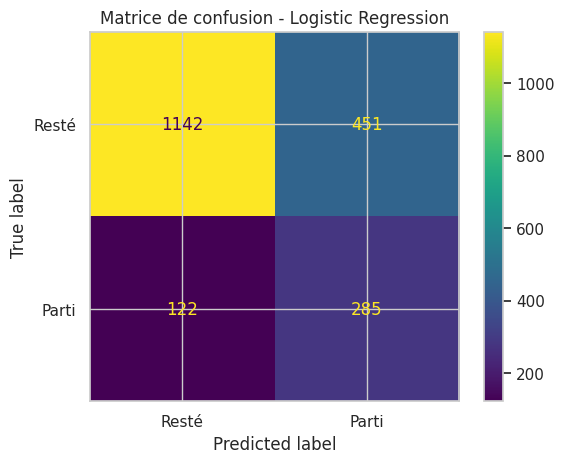

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Resté", "Parti"]
)

disp.plot()
plt.title("Matrice de confusion - Logistic Regression")
plt.show()

In [ ]:
logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "ROC-AUC": roc_auc
}

print(logistic_results)

{'Model': 'Logistic Regression', 'Accuracy': 0.7135, 'Precision': 0.38722826086956524, 'Recall': 0.7002457002457002, 'F1-score': 0.49868766404199477, 'ROC-AUC': np.float64(0.7771654551315569)}


In [ ]:
from sklearn.ensemble import RandomForestClassifier
# Création du pipeline Random Forest

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Pipeline Random Forest créé avec succès.")

Pipeline Random Forest créé avec succès.


In [ ]:
# Entraînement du modèle

rf_model.fit(X_train, y_train)

print("Random Forest entraîné avec succès.")

Random Forest entraîné avec succès.


In [ ]:
# Prédictions

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Prédictions Random Forest effectuées.")

Prédictions Random Forest effectuées.


In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print("Accuracy :", accuracy_rf)
print("Precision :", precision_rf)
print("Recall :", recall_rf)
print("F1-score :", f1_rf)
print("ROC-AUC :", roc_auc_rf)

Accuracy : 0.859
Precision : 0.7659574468085106
Recall : 0.44226044226044225
F1-score : 0.5607476635514018
ROC-AUC : 0.8532029718470397


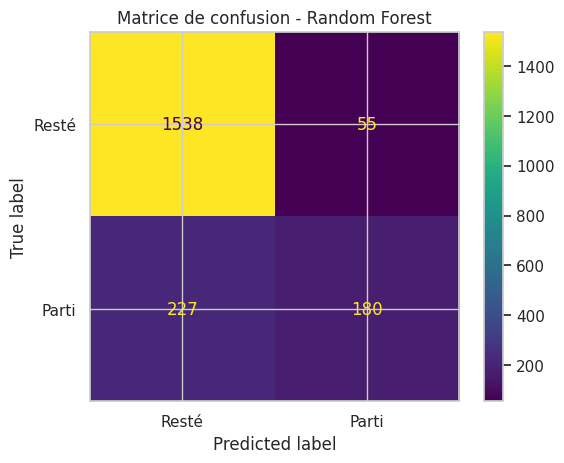

In [ ]:


cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Resté", "Parti"]
)

disp.plot()
plt.title("Matrice de confusion - Random Forest")
plt.show()

In [ ]:
from xgboost import XGBClassifier
# Poids de la classe minoritaire

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("Scale pos weight :", scale_pos_weight)

Scale pos weight : 3.9079754601226995


In [ ]:
# Création du pipeline XGBoost

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        ))
    ]
)

print("Pipeline XGBoost créé avec succès.")

Pipeline XGBoost créé avec succès.


In [ ]:
# Entraînement du modèle

xgb_model.fit(X_train, y_train)

print("XGBoost entraîné avec succès.")

XGBoost entraîné avec succès.


In [ ]:
# Prédictions

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Prédictions XGBoost effectuées.")

Prédictions XGBoost effectuées.


In [ ]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print("Accuracy :", accuracy_xgb)
print("Precision :", precision_xgb)
print("Recall :", recall_xgb)
print("F1-score :", f1_xgb)
print("ROC-AUC :", roc_auc_xgb)

Accuracy : 0.8095
Precision : 0.5233812949640287
Recall : 0.714987714987715
F1-score : 0.6043613707165109
ROC-AUC : 0.8581971802310785


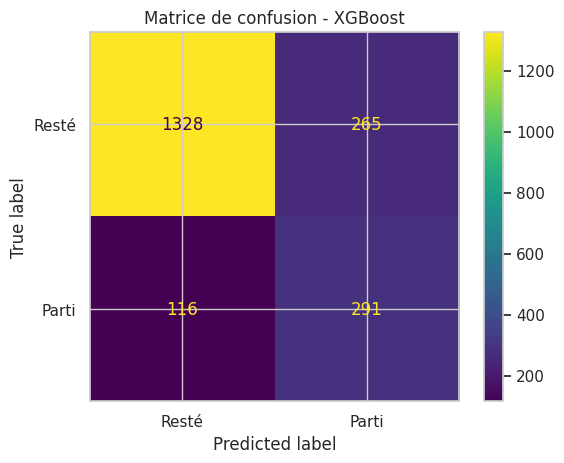

In [ ]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["Resté", "Parti"]
)

disp.plot()
plt.title("Matrice de confusion - XGBoost")
plt.show()

In [ ]:
from sklearn.metrics import average_precision_score, roc_curve, precision_recall_curve

def evaluate(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
    }

results_df = pd.DataFrame([
    evaluate("Logistic Regression", y_test, y_pred, y_proba),
    evaluate("Random Forest", y_test, y_pred_rf, y_proba_rf),
    evaluate("XGBoost", y_test, y_pred_xgb, y_proba_xgb),
]).set_index("Model").round(4)

results_df.sort_values("ROC-AUC", ascending=False)

,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
Model,,,,,,
XGBoost,0.8095,0.5234,0.7150,0.6044,0.8582,0.7071
Random Forest,0.8590,0.7660,0.4423,0.5607,0.8532,0.6729
Logistic Regression,0.7135,0.3872,0.7002,0.4987,0.7772,0.4679


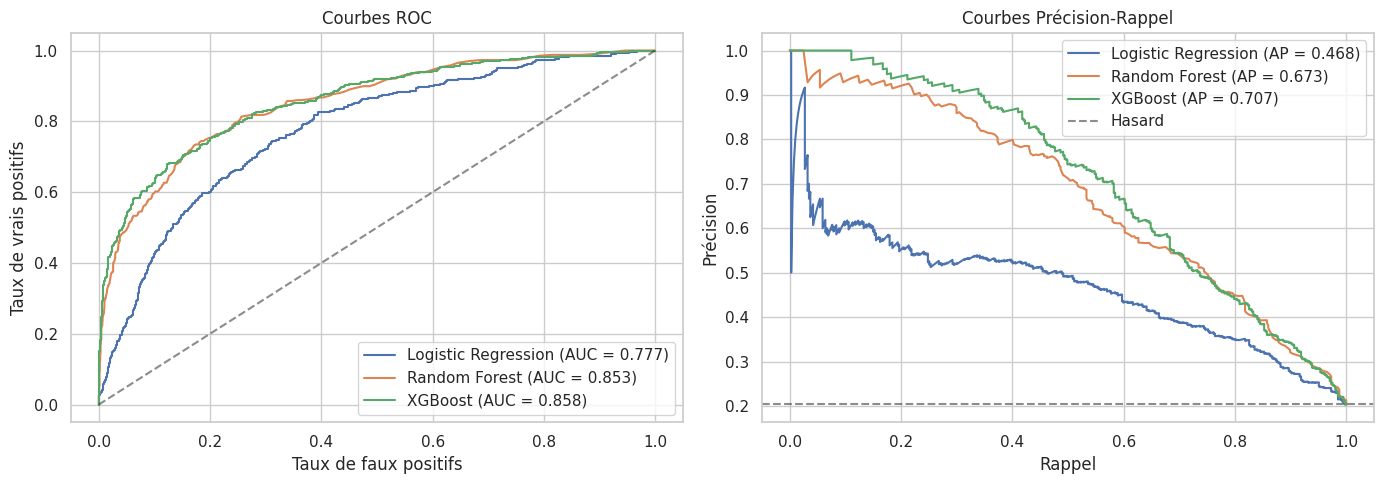

In [ ]:
probas = {
    "Logistic Regression": y_proba,
    "Random Forest": y_proba_rf,
    "XGBoost": y_proba_xgb,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, p in probas.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, p):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set_title("Courbes ROC")
axes[0].set_xlabel("Taux de faux positifs")
axes[0].set_ylabel("Taux de vrais positifs")
axes[0].legend()

for name, p in probas.items():
    prec, rec, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rec, prec, label=f"{name} (AP = {average_precision_score(y_test, p):.3f})")
axes[1].axhline(y_test.mean(), color="k", linestyle="--", alpha=0.5, label="Hasard")
axes[1].set_title("Courbes Précision-Rappel")
axes[1].set_xlabel("Rappel")
axes[1].set_ylabel("Précision")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
}

base_models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
}

cv_rows = []
for name, model in base_models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    row = {"Model": name}
    for metric in scoring:
        vals = scores[f"test_{metric}"]
        row[metric] = f"{vals.mean():.3f} ± {vals.std():.3f}"
    cv_rows.append(row)

pd.DataFrame(cv_rows).set_index("Model")

,roc_auc,pr_auc,f1,recall,precision
Model,,,,,
Logistic Regression,0.766 ± 0.021,0.457 ± 0.029,0.489 ± 0.019,0.686 ± 0.036,0.380 ± 0.014
Random Forest,0.850 ± 0.013,0.661 ± 0.016,0.559 ± 0.026,0.438 ± 0.027,0.773 ± 0.018
XGBoost,0.858 ± 0.011,0.689 ± 0.025,0.608 ± 0.013,0.698 ± 0.032,0.539 ± 0.003


In [ ]:
import optuna
from sklearn.base import clone
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def build_xgb(params):
    return Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("classifier", XGBClassifier(
            **params,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1,
        )),
    ])

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
    }
    scores = cross_val_score(build_xgb(params), X_train, y_train,
                             cv=cv, scoring="average_precision", n_jobs=1)
    return scores.mean()

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=40, show_progress_bar=True)

print("Meilleure PR-AUC (CV) :", round(study.best_value, 4))
print(study.best_params)

  0%|          | 0/40 [00:00<?, ?it/s]

Meilleure PR-AUC (CV) : 0.7028
{'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.013881659113007429, 'subsample': 0.7660785428750863, 'colsample_bytree': 0.6023871456857379, 'min_child_weight': 7, 'gamma': 3.6671317075594434, 'reg_lambda': 0.23145010020996196}


In [ ]:
xgb_tuned = build_xgb(study.best_params)
xgb_tuned.fit(X_train, y_train)

y_proba_tuned = xgb_tuned.predict_proba(X_test)[:, 1]
y_pred_tuned = (y_proba_tuned >= 0.5).astype(int)

results_df.loc["XGBoost (optimisé)"] = pd.Series(
    evaluate("XGBoost (optimisé)", y_test, y_pred_tuned, y_proba_tuned)
).drop("Model").astype(float).round(4)

results_df.sort_values("ROC-AUC", ascending=False)

,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
Model,,,,,,
XGBoost (optimisé),0.8120,0.5270,0.7445,0.6171,0.8639,0.7153
XGBoost,0.8095,0.5234,0.7150,0.6044,0.8582,0.7071
Random Forest,0.8590,0.7660,0.4423,0.5607,0.8532,0.6729
Logistic Regression,0.7135,0.3872,0.7002,0.4987,0.7772,0.4679


Seuil optimal (F1)                  : 0.60
Seuil optimal (coût)                : 0.22
Seuil (précision >= 0.60)        : 0.59


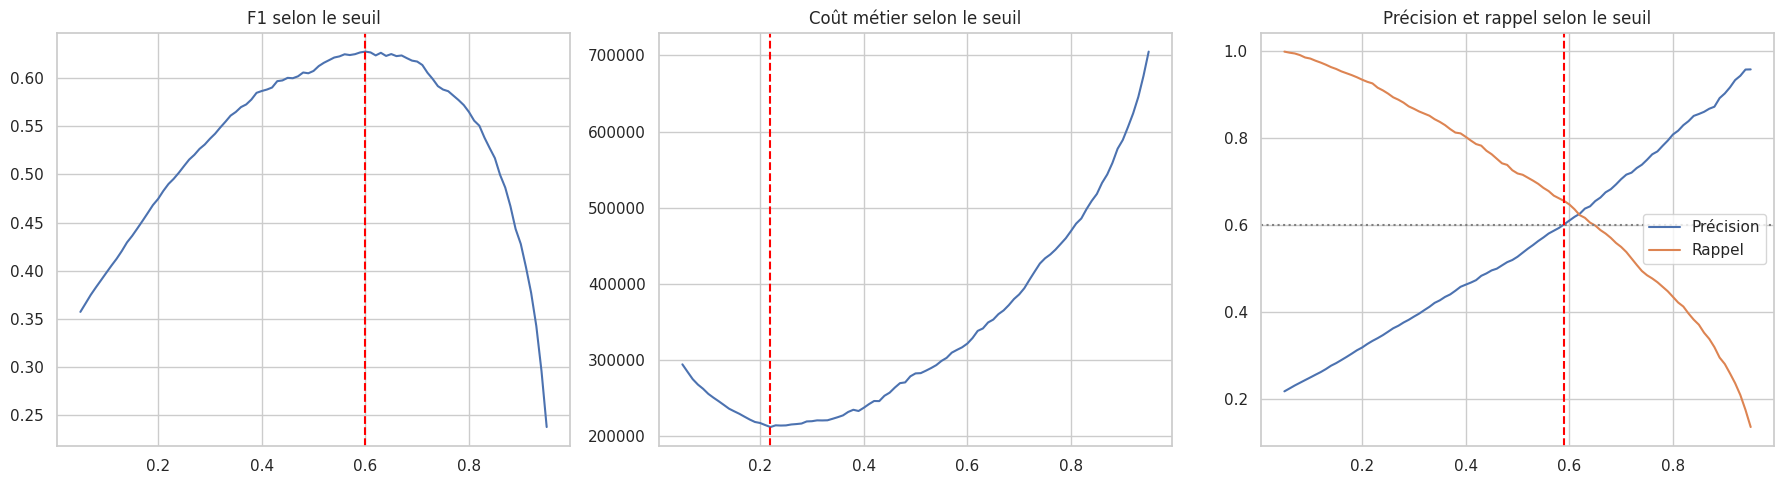

In [ ]:
from sklearn.model_selection import cross_val_predict

oof_proba = cross_val_predict(clone(xgb_tuned), X_train, y_train,
                              cv=cv, method="predict_proba", n_jobs=1)[:, 1]

y_train_arr = y_train.values
thresholds = np.linspace(0.05, 0.95, 91)

COST_FN = 500        # client perdu non détecté (hypothèse)
COST_FP = 50         # offre de rétention envoyée pour rien (hypothèse)
MIN_PRECISION = 0.60 # précision minimale souhaitée

f1_by_thr, cost_by_thr, prec_by_thr, rec_by_thr = [], [], [], []
for t in thresholds:
    pred = (oof_proba >= t).astype(int)
    fn = ((pred == 0) & (y_train_arr == 1)).sum()
    fp = ((pred == 1) & (y_train_arr == 0)).sum()
    f1_by_thr.append(f1_score(y_train_arr, pred))
    cost_by_thr.append(fn * COST_FN + fp * COST_FP)
    prec_by_thr.append(precision_score(y_train_arr, pred, zero_division=0))
    rec_by_thr.append(recall_score(y_train_arr, pred))

prec_by_thr = np.array(prec_by_thr)
rec_by_thr = np.array(rec_by_thr)

best_thr_f1 = thresholds[int(np.argmax(f1_by_thr))]
best_thr_cost = thresholds[int(np.argmin(cost_by_thr))]

ok = prec_by_thr >= MIN_PRECISION
if ok.any():
    best_thr_prec = thresholds[ok][int(np.argmax(rec_by_thr[ok]))]
else:
    best_thr_prec = best_thr_f1
    print("Aucun seuil n'atteint la précision demandée, on garde le seuil F1.")

print(f"Seuil optimal (F1)                  : {best_thr_f1:.2f}")
print(f"Seuil optimal (coût)                : {best_thr_cost:.2f}")
print(f"Seuil (précision >= {MIN_PRECISION:.2f})        : {best_thr_prec:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(thresholds, f1_by_thr)
axes[0].axvline(best_thr_f1, color="red", linestyle="--")
axes[0].set_title("F1 selon le seuil")
axes[1].plot(thresholds, cost_by_thr)
axes[1].axvline(best_thr_cost, color="red", linestyle="--")
axes[1].set_title("Coût métier selon le seuil")
axes[2].plot(thresholds, prec_by_thr, label="Précision")
axes[2].plot(thresholds, rec_by_thr, label="Rappel")
axes[2].axhline(MIN_PRECISION, color="gray", linestyle=":")
axes[2].axvline(best_thr_prec, color="red", linestyle="--")
axes[2].set_title("Précision et rappel selon le seuil")
axes[2].legend()
plt.tight_layout()
plt.show()

In [ ]:
rows = []
for label, thr in [("Seuil 0.50", 0.5),
                   (f"Seuil F1 ({best_thr_f1:.2f})", best_thr_f1),
                   (f"Seuil coût ({best_thr_cost:.2f})", best_thr_cost),
                   (f"Seuil précision ({best_thr_prec:.2f})", best_thr_prec)]:
    pred = (y_proba_tuned >= thr).astype(int)
    fn = ((pred == 0) & (y_test.values == 1)).sum()
    fp = ((pred == 1) & (y_test.values == 0)).sum()
    rows.append({
        "Seuil": label,
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred),
        "F1-score": f1_score(y_test, pred),
        "Clients ciblés": int(pred.sum()),
        "Coût total": int(fn * COST_FN + fp * COST_FP),
    })

pd.DataFrame(rows).set_index("Seuil").round(3)

,Precision,Recall,F1-score,Clients ciblés,Coût total
Seuil,,,,,
Seuil 0.50,0.527,0.744,0.617,575,65600
Seuil F1 (0.60),0.606,0.654,0.629,439,79150
Seuil coût (0.22),0.319,0.914,0.473,1167,57250
Seuil précision (0.59),0.599,0.661,0.629,449,78000


Seuil retenu : 0.60

              precision    recall  f1-score   support

       Resté       0.91      0.89      0.90      1593
       Parti       0.61      0.65      0.63       407

    accuracy                           0.84      2000
   macro avg       0.76      0.77      0.76      2000
weighted avg       0.85      0.84      0.85      2000



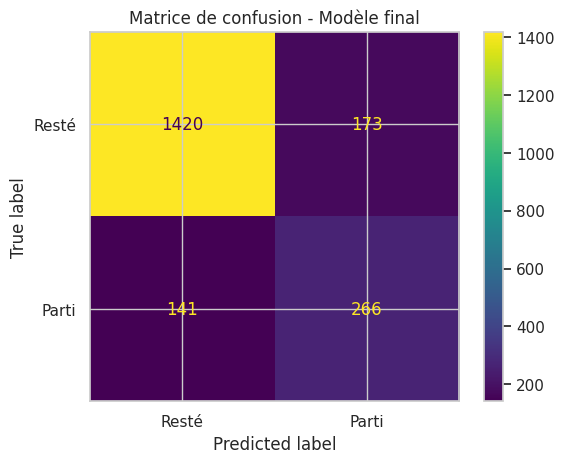

In [ ]:
final_model = xgb_tuned
FINAL_THRESHOLD = float(best_thr_f1)   # change ici si besoin

y_proba_final = final_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba_final >= FINAL_THRESHOLD).astype(int)

print(f"Seuil retenu : {FINAL_THRESHOLD:.2f}\n")
print(classification_report(y_test, y_pred_final, target_names=["Resté", "Parti"]))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_final),
                       display_labels=["Resté", "Parti"]).plot()
plt.title("Matrice de confusion - Modèle final")
plt.show()

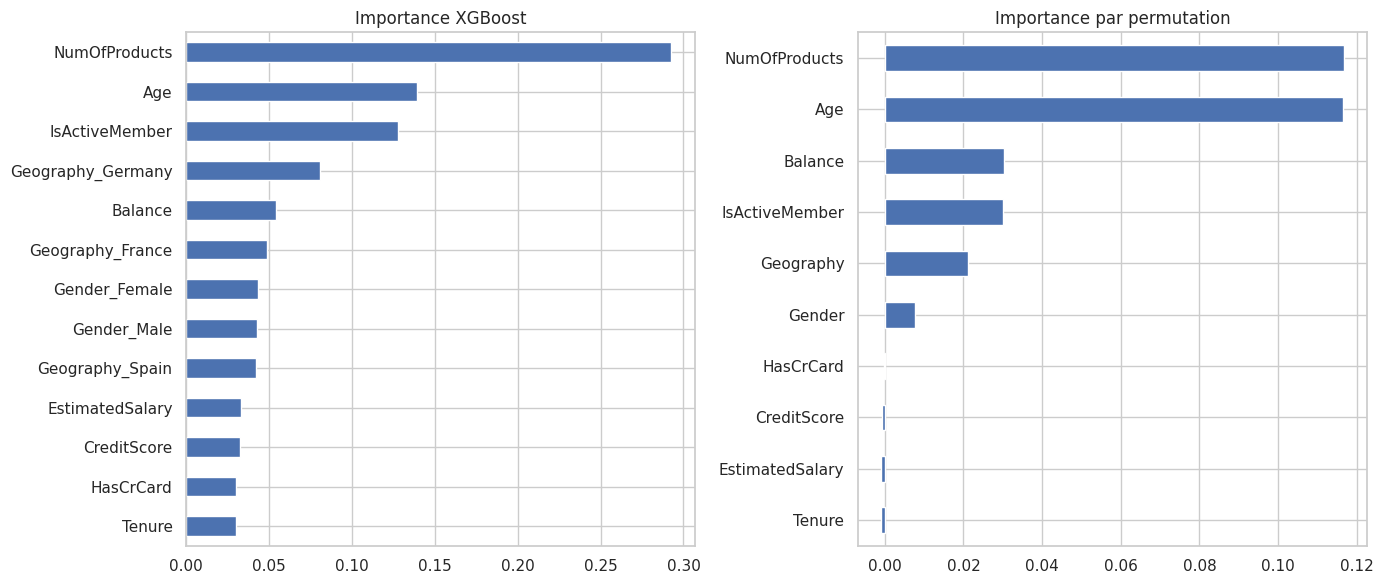

In [ ]:
from sklearn.inspection import permutation_importance

prep = final_model.named_steps["preprocessor"]
clf = final_model.named_steps["classifier"]
feature_names = [n.split("__", 1)[1] for n in prep.get_feature_names_out()]

imp = pd.Series(clf.feature_importances_, index=feature_names).sort_values()

perm = permutation_importance(final_model, X_test, y_test, scoring="roc_auc",
                              n_repeats=10, random_state=42, n_jobs=1)
perm_imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
imp.plot(kind="barh", ax=axes[0]); axes[0].set_title("Importance XGBoost")
perm_imp.plot(kind="barh", ax=axes[1]); axes[1].set_title("Importance par permutation")
plt.tight_layout()
plt.show()

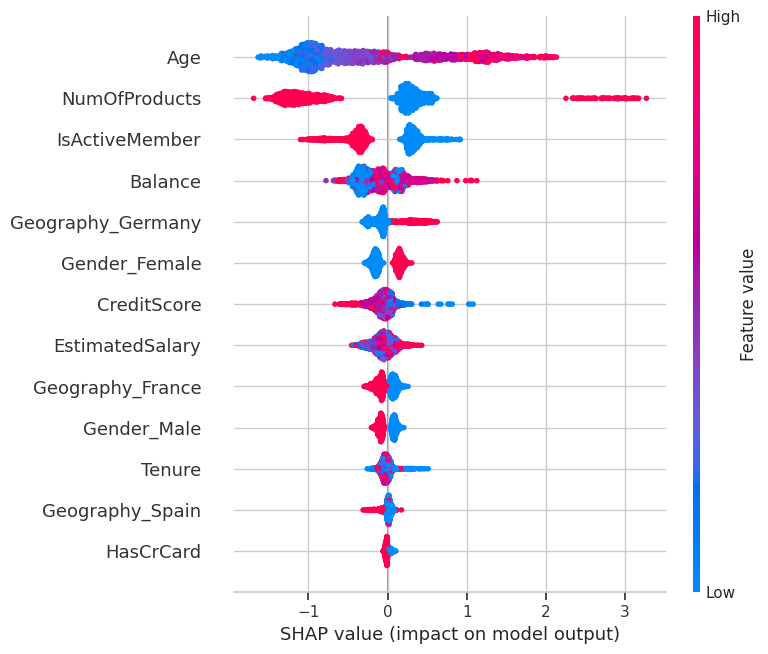

In [ ]:
import shap

X_test_t = prep.transform(X_test)
if hasattr(X_test_t, "toarray"):
    X_test_t = X_test_t.toarray()
X_test_t = pd.DataFrame(X_test_t, columns=feature_names)

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_t)

shap.summary_plot(shap_values, X_test_t, show=False)
plt.tight_layout()
plt.show()

,clients,churners,churn_rate,lift,captured_%
decile,,,,,
1,200,171,0.855,4.201,42.015
2,200,86,0.430,2.113,63.145
3,200,47,0.235,1.155,74.693
4,200,30,0.150,0.737,82.064
5,200,27,0.135,0.663,88.698
6,200,16,0.080,0.393,92.629
7,200,12,0.060,0.295,95.577
8,200,9,0.045,0.221,97.789
9,200,5,0.025,0.123,99.017


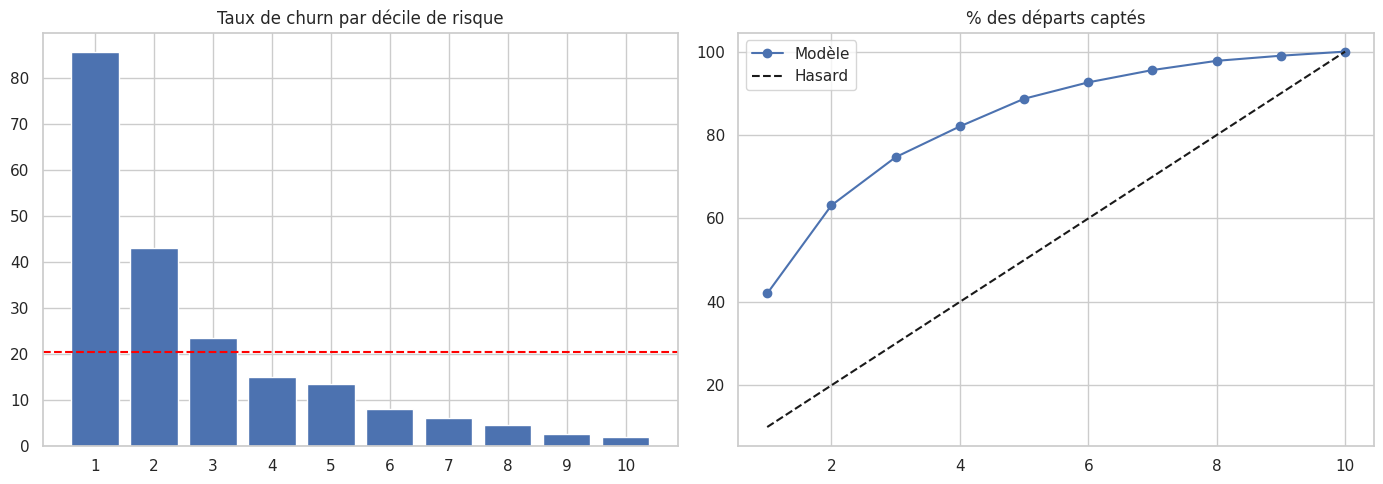

In [ ]:
lift_df = pd.DataFrame({"y": y_test.values, "p": y_proba_final})
lift_df["decile"] = pd.qcut(lift_df["p"].rank(method="first", ascending=False),
                            10, labels=range(1, 11))

lift = lift_df.groupby("decile", observed=True).agg(
    clients=("y", "size"), churners=("y", "sum"), churn_rate=("y", "mean"))
lift["lift"] = lift["churn_rate"] / lift_df["y"].mean()
lift["captured_%"] = lift["churners"].cumsum() / lift["churners"].sum() * 100
display(lift.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(lift.index.astype(str), lift["churn_rate"] * 100)
axes[0].axhline(lift_df["y"].mean() * 100, color="red", linestyle="--")
axes[0].set_title("Taux de churn par décile de risque")
axes[1].plot(range(1, 11), lift["captured_%"], marker="o", label="Modèle")
axes[1].plot(range(1, 11), np.arange(1, 11) * 10, "k--", label="Hasard")
axes[1].set_title("% des départs captés")
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
import joblib

def risk_segment(p):
    if p >= 0.70:
        return "Élevé"
    elif p >= FINAL_THRESHOLD:
        return "Moyen"
    return "Faible"

scored = X_test.copy()
scored["Churn_Proba"] = y_proba_final.round(4)
scored["Risk_Segment"] = scored["Churn_Proba"].apply(risk_segment)
scored["Exited_Reel"] = y_test.values

print(scored["Risk_Segment"].value_counts())
display(scored.sort_values("Churn_Proba", ascending=False).head(10))

MODEL_DIR = PROJECT_PATH.parent
joblib.dump({"model": final_model, "threshold": FINAL_THRESHOLD,
             "features": X.columns.tolist()}, MODEL_DIR / "churn_model.joblib")
scored.sort_values("Churn_Proba", ascending=False).to_csv(MODEL_DIR / "clients_scores.csv")

Risk_Segment
Faible    1561
Élevé      322
Moyen      117
Name: count, dtype: int64


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn_Proba,Risk_Segment,Exited_Reel
6255,547,Germany,Male,55,4,111362.76,3,1,0,16922.28,0.9954,Élevé,1
5950,834,Germany,Female,57,8,112281.60,3,1,0,140225.14,0.9950,Élevé,1
70,738,Germany,Male,58,2,133745.44,4,1,0,28373.86,0.9948,Élevé,1
3549,675,France,Female,61,5,62055.17,3,1,0,166305.16,0.9936,Élevé,1
6831,469,Germany,Female,52,8,139493.25,3,0,0,150093.32,0.9927,Élevé,1
9540,727,Germany,Male,46,3,115248.11,4,1,0,130752.01,0.9907,Élevé,1
871,629,Germany,Female,45,7,129818.39,3,1,0,9217.55,0.9873,Élevé,1
1798,714,France,Female,51,4,88308.87,3,0,0,5862.53,0.9867,Élevé,1
555,590,Spain,Female,51,3,154962.99,3,0,1,191932.27,0.9867,Élevé,1
5010,575,Germany,Male,49,7,121205.15,4,1,1,168080.53,0.9854,Élevé,1


In [ ]:
artifact = joblib.load(MODEL_DIR / "churn_model.joblib")

def predict_churn(new_customers):
    proba = artifact["model"].predict_proba(new_customers[artifact["features"]])[:, 1]
    out = new_customers.copy()
    out["Churn_Proba"] = proba.round(4)
    out["Prediction"] = np.where(proba >= artifact["threshold"], "Parti", "Reste")
    return out

predict_churn(X_test.head(5))

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn_Proba,Prediction
5702,585,France,Male,36,7,0.00,2,1,0,94283.09,0.0697,Reste
3667,525,Germany,Male,33,4,131023.76,2,0,0,55072.93,0.2491,Reste
1617,557,Spain,Female,40,4,0.00,2,0,1,105433.53,0.1098,Reste
5673,639,Spain,Male,34,5,139393.19,2,0,0,33950.08,0.1400,Reste
4272,640,Spain,Female,34,3,77826.80,1,1,1,168544.85,0.2311,Reste


In [ ]:
display(results_df.sort_values("ROC-AUC", ascending=False))

print("Modèle final au seuil", round(FINAL_THRESHOLD, 2), ":",
      "Precision =", round(precision_score(y_test, y_pred_final), 3),
      "| Recall =", round(recall_score(y_test, y_pred_final), 3),
      "| F1 =", round(f1_score(y_test, y_pred_final), 3))

,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
Model,,,,,,
XGBoost (optimisé),0.8120,0.5270,0.7445,0.6171,0.8639,0.7153
XGBoost,0.8095,0.5234,0.7150,0.6044,0.8582,0.7071
Random Forest,0.8590,0.7660,0.4423,0.5607,0.8532,0.6729
Logistic Regression,0.7135,0.3872,0.7002,0.4987,0.7772,0.4679


Modèle final au seuil 0.6 : Precision = 0.606 | Recall = 0.654 | F1 = 0.629
